In [4]:
from google.colab import drive

drive.mount('/content/drive')

import pandas as pd

from pathlib import Path
from IPython.display import Image, display

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# ECE 533 Final Project

# Deep Learning-Based Lunar Crater Detection Using Object Detection Architectures

## Scott Nguyen

### University of New Mexico

### ECE 533

### Spring 2026

---

# 1. Introduction

This project presents the development and evaluation of multiple deep learning object detection architectures for automated lunar crater detection using annotated planetary surface imagery.

The project investigates the effectiveness of:

* YOLOv8 Nano
* Faster R-CNN
* RetinaNet

The workflow includes:

* dataset preparation
* dataset inspection
* ground truth visualization
* model training
* prediction visualization
* quantitative accuracy evaluation
* computational performance analysis

All experiments were implemented in Google Colab using GPU acceleration.

---

# 2. Dataset Description

The crater detection dataset was obtained from KaggleHub and contains annotated lunar and Martian surface imagery formatted for YOLO-based object detection workflows.

Dataset source:
https://www.kaggle.com/datasets/lincolnzh/martianlunar-crater-detection-dataset

The dataset is divided into:

* training images
* validation images
* testing images

Each image contains crater bounding box annotations used for supervised object detection training.

# 3. Dataset Summary and Inspection

The dataset was inspected prior to training to verify:

* image counts
* annotation counts
* dataset split integrity
* crater bounding box formatting

Ground truth crater annotations were visualized to confirm correct annotation alignment across the dataset.


In [7]:
summary_path = (
    "/content/drive/MyDrive/"
    "ece-533-final-project/logs/"
    "dataset_summary.csv"
)

summary_df = pd.read_csv(summary_path)

summary_df


,split,num_images,num_label_files,num_crater_boxes,num_empty_labels
0,train,98,98,681,9
1,valid,26,26,202,2
2,test,19,19,151,0


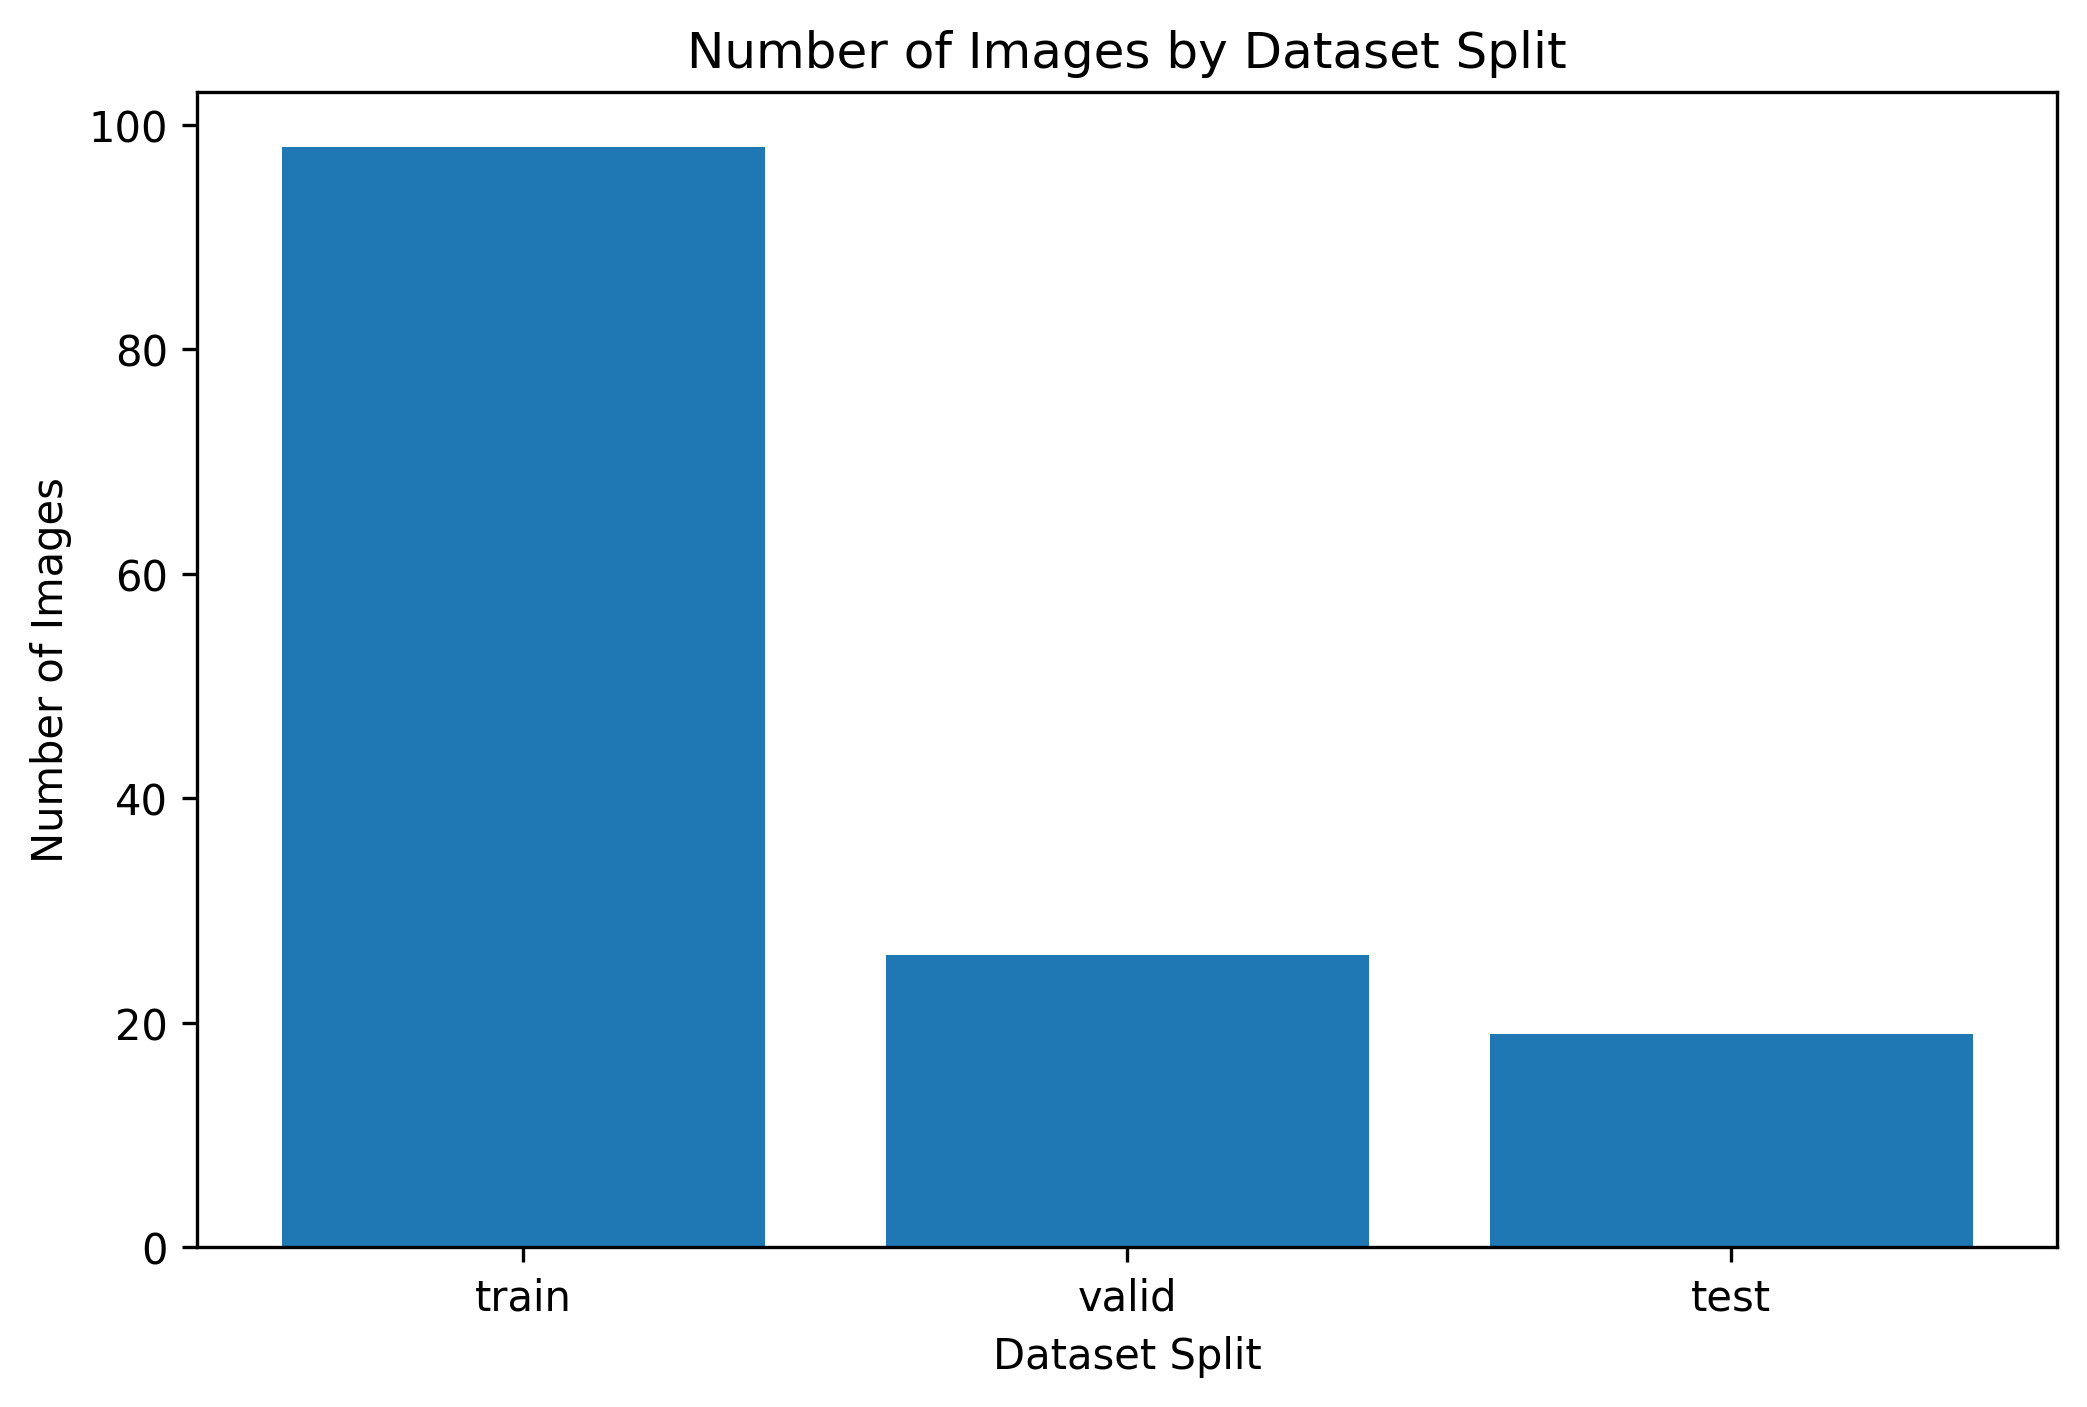

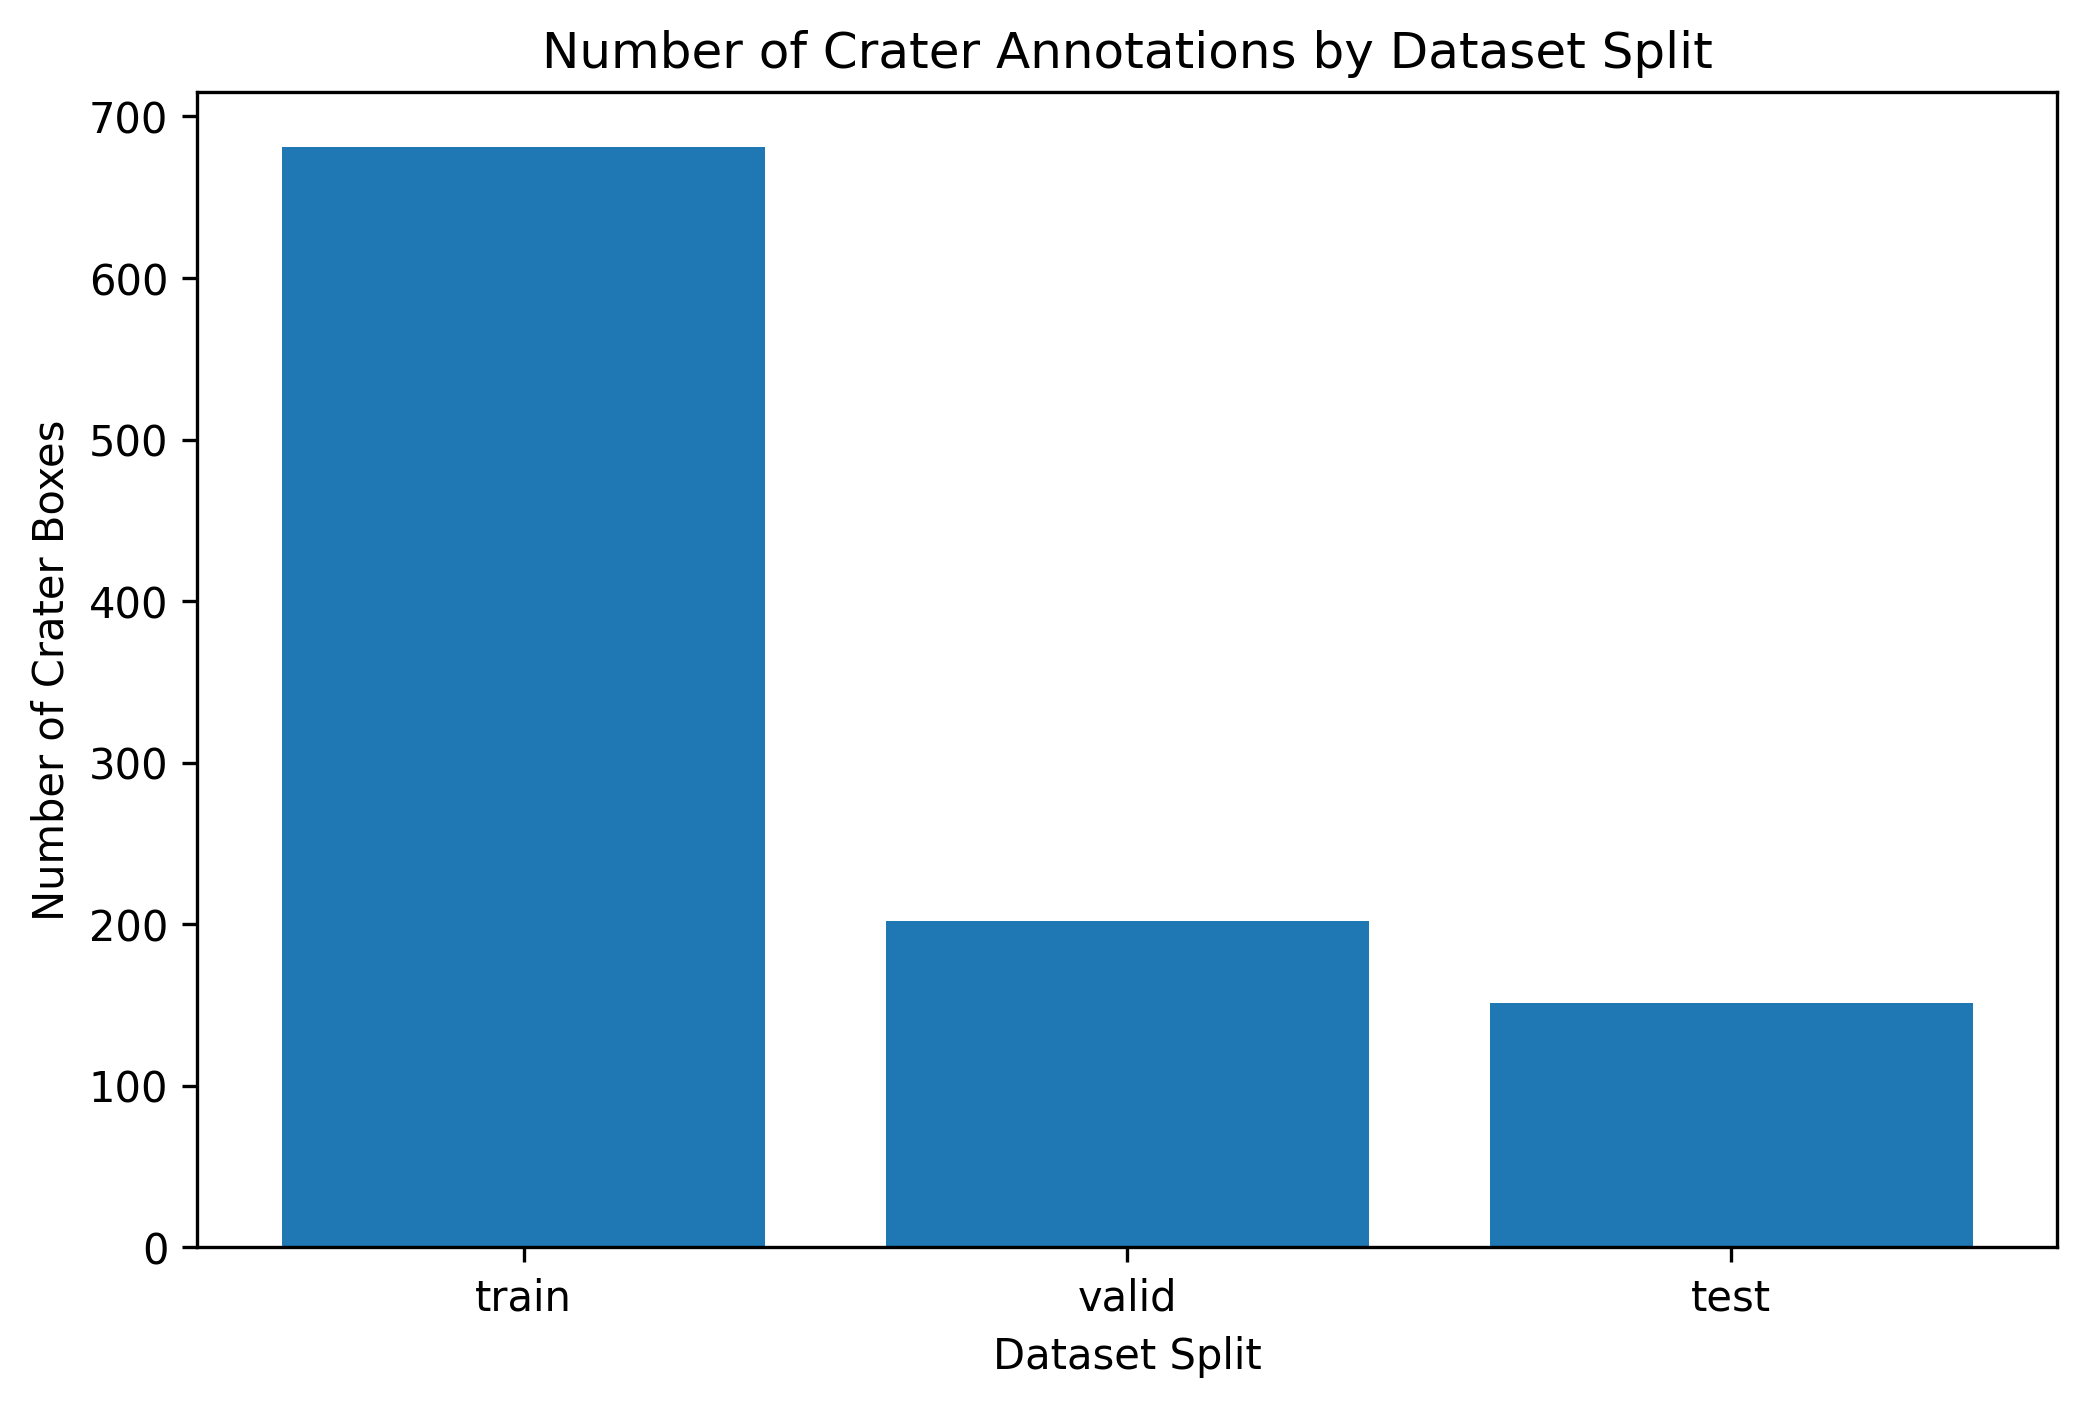

In [8]:
display(
    Image(
        filename=(
            "/content/drive/MyDrive/"
            "ece-533-final-project/"
            "dataset_outputs/plots/"
            "dataset_image_distribution.png"
        )
    )
)

display(
    Image(
        filename=(
            "/content/drive/MyDrive/"
            "ece-533-final-project/"
            "dataset_outputs/plots/"
            "dataset_annotation_distribution.png"
        )
    )
)

# 4. Ground Truth Bounding Box Visualization

Ground truth crater bounding boxes were visualized across the dataset to validate annotation quality before training.

Annotated crater examples demonstrated that the dataset labels were correctly aligned with crater structures within the lunar imagery.


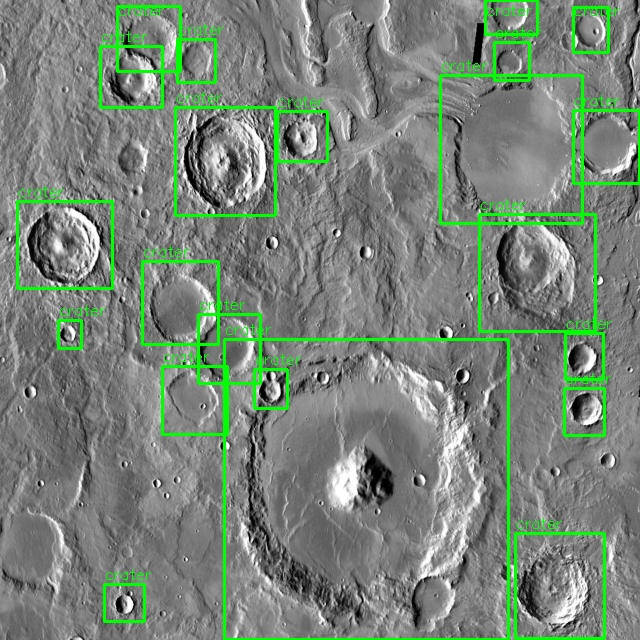

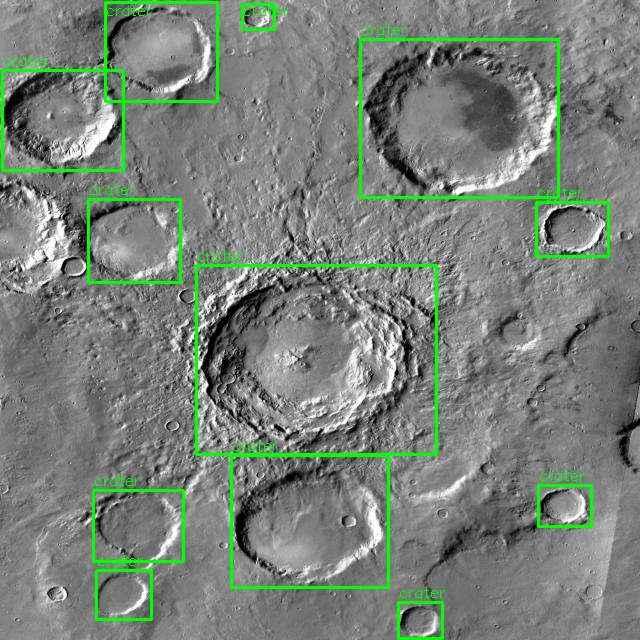

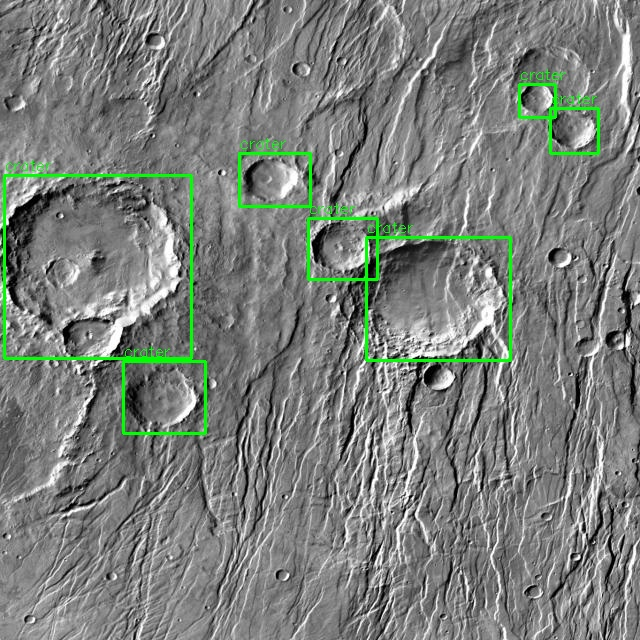

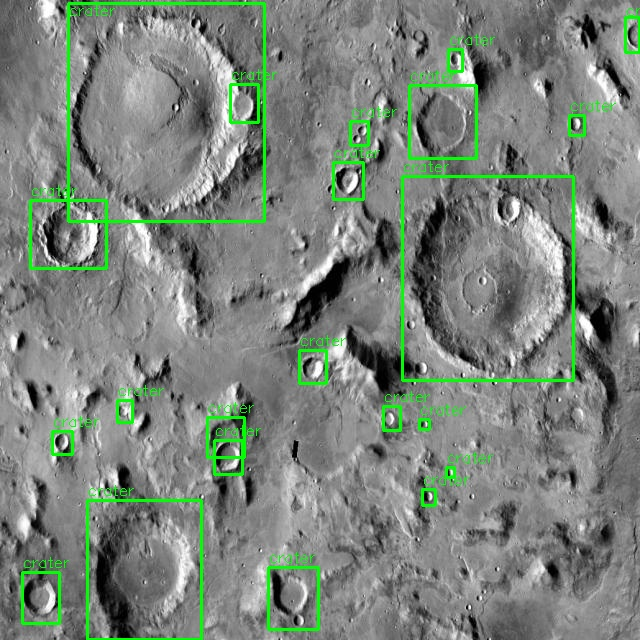

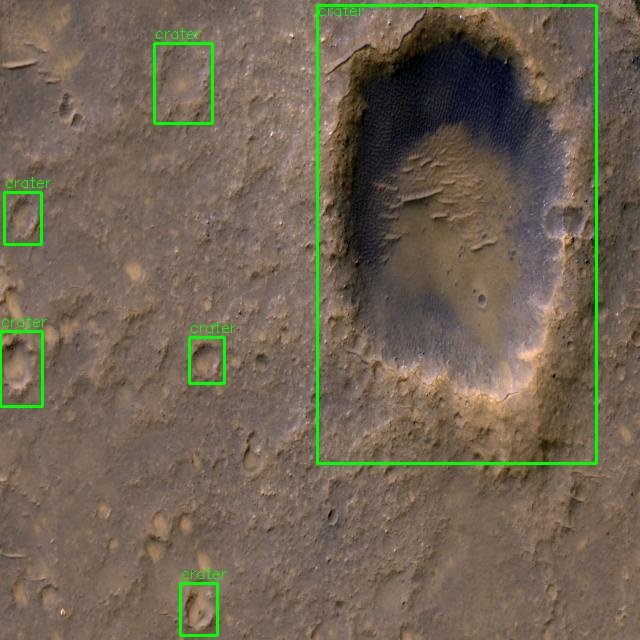

In [9]:
ground_truth_dir = Path(
    "/content/drive/MyDrive/"
    "ece-533-final-project/"
    "dataset_outputs/ground_truth"
)

example_images = sorted(
    list(ground_truth_dir.glob("*.jpg"))
)[:5]

for image_path in example_images:

    display(
        Image(filename=str(image_path))
    )

# 5. Model Training Methodology

Three object detection architectures were trained and evaluated:

* YOLOv8 Nano
* Faster R-CNN
* RetinaNet

All models were trained using consistent dataset splits and comparable training configurations to ensure fair experimental comparison.

The training workflow included:

* GPU-accelerated training in Google Colab
* model checkpoint saving
* timing analysis
* training log generation
* prediction visualization
* quantitative evaluation

Training metrics and computational timing statistics were saved throughout the experiments.

# 6. Results

The trained crater detection models were evaluated using:

* prediction visualization
* mAP-based accuracy metrics
* training duration
* inference speed
* computational efficiency

YOLOv8 demonstrated the fastest training and inference performance while maintaining strong crater localization capability.

Faster R-CNN and RetinaNet also achieved successful crater detection performance but required greater computational resources and longer execution times.

Prediction visualizations demonstrated that all evaluated models were capable of identifying crater structures across diverse lunar terrain conditions.

In [10]:
accuracy_path = (
    "/content/drive/MyDrive/"
    "ece-533-final-project/logs/"
    "accuracy_evaluation_results.csv"
)

accuracy_df = pd.read_csv(
    accuracy_path
)

accuracy_df

,model,mAP50,mAP50_95,mAP75,precision,recall
0,yolov8n,0.563337,0.317953,0.309745,0.317953,0.381457
1,faster_rcnn_crater,0.533804,0.287058,0.297832,0.287058,0.358278
2,retinanet_crater,0.575287,0.293967,0.287411,0.293967,0.370861


In [11]:
comparison_path = (
    "/content/drive/MyDrive/"
    "ece-533-final-project/logs/"
    "model_comparison_summary.csv"
)

comparison_df = pd.read_csv(
    comparison_path
)

comparison_df

,model,training_log_found,training_total_time_sec,training_avg_epoch_time_sec,training_final_loss,training_best_loss,num_test_images,total_detections,avg_detections_per_image,inference_total_time_sec,inference_avg_time_per_image_sec,inference_fps
0,faster_rcnn_crater,True,1098.359428,21.967189,0.081283,0.063145,19,135,7.105263,1.592319,0.083806,11.932279
1,retinanet_crater,True,1008.029006,20.160580,0.086646,0.086646,19,127,6.684211,1.437856,0.075677,13.214115
2,yolov8n,True,182.787466,3.655749,1.305340,1.200210,19,125,6.578947,0.804036,0.042318,23.630779


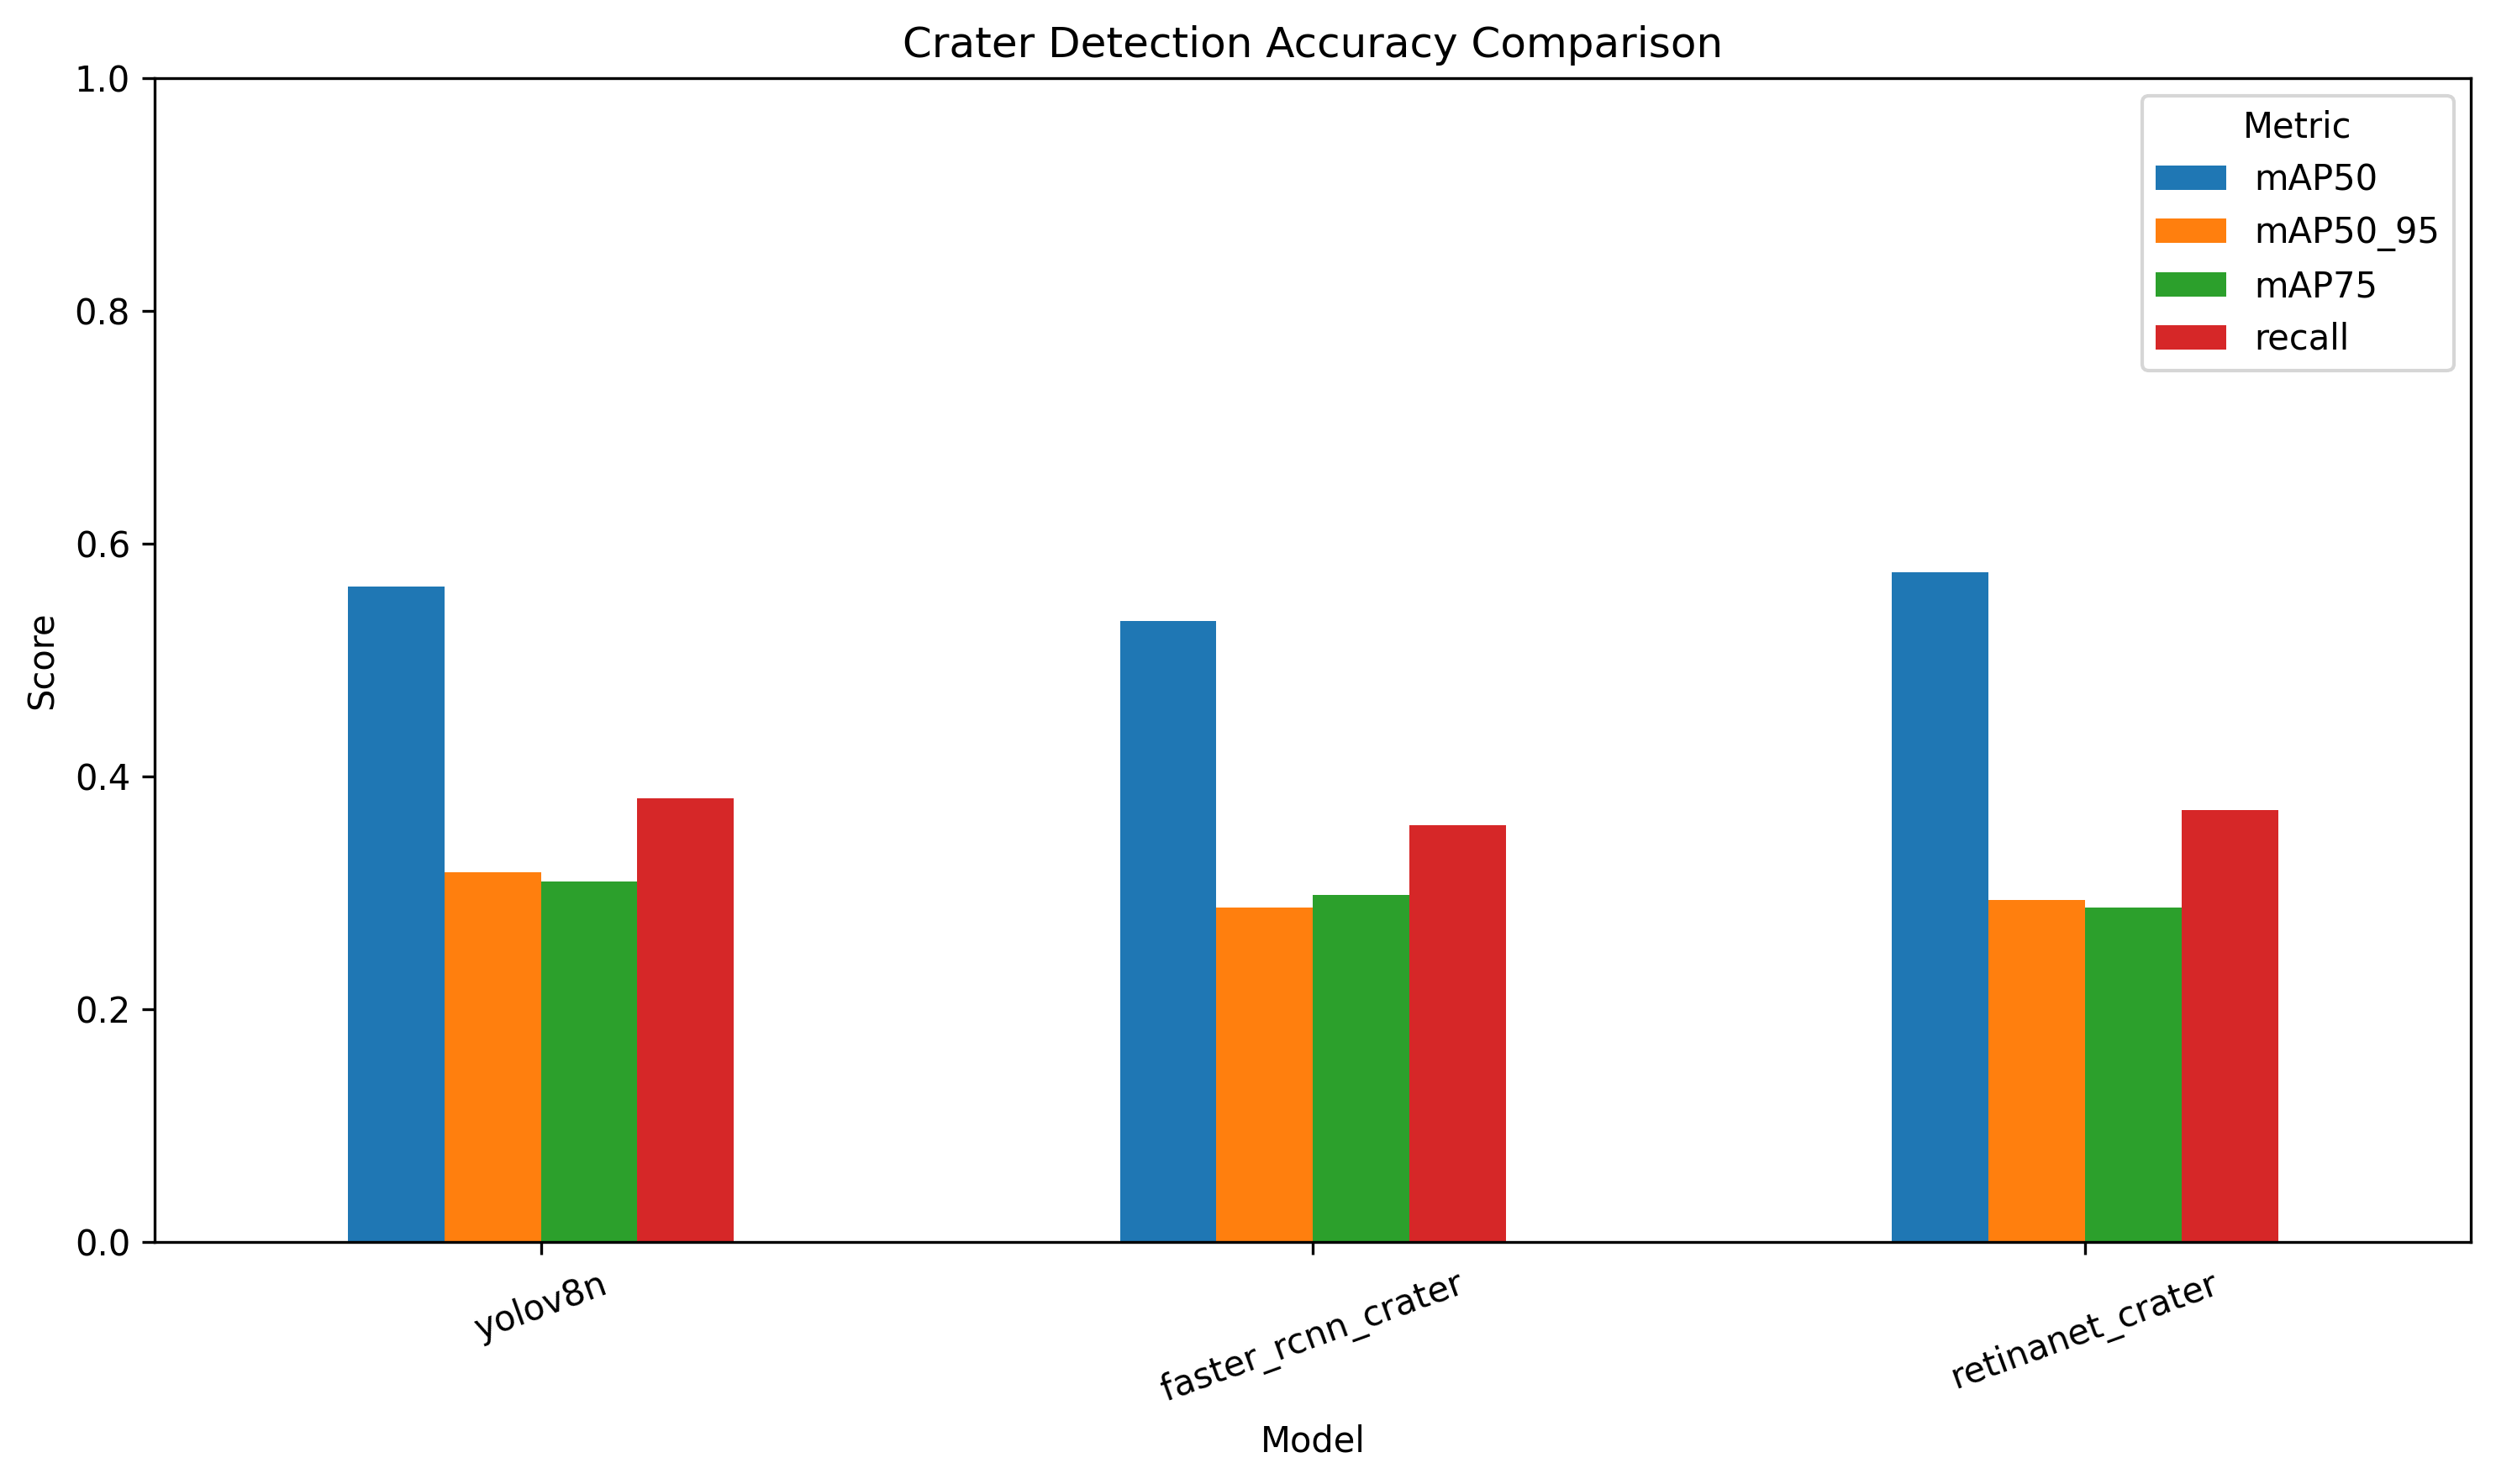

In [12]:
display(
    Image(
        filename=(
            "/content/drive/MyDrive/"
            "ece-533-final-project/"
            "comparison_outputs/plots/"
            "accuracy_metrics_comparison.png"
        )
    )
)

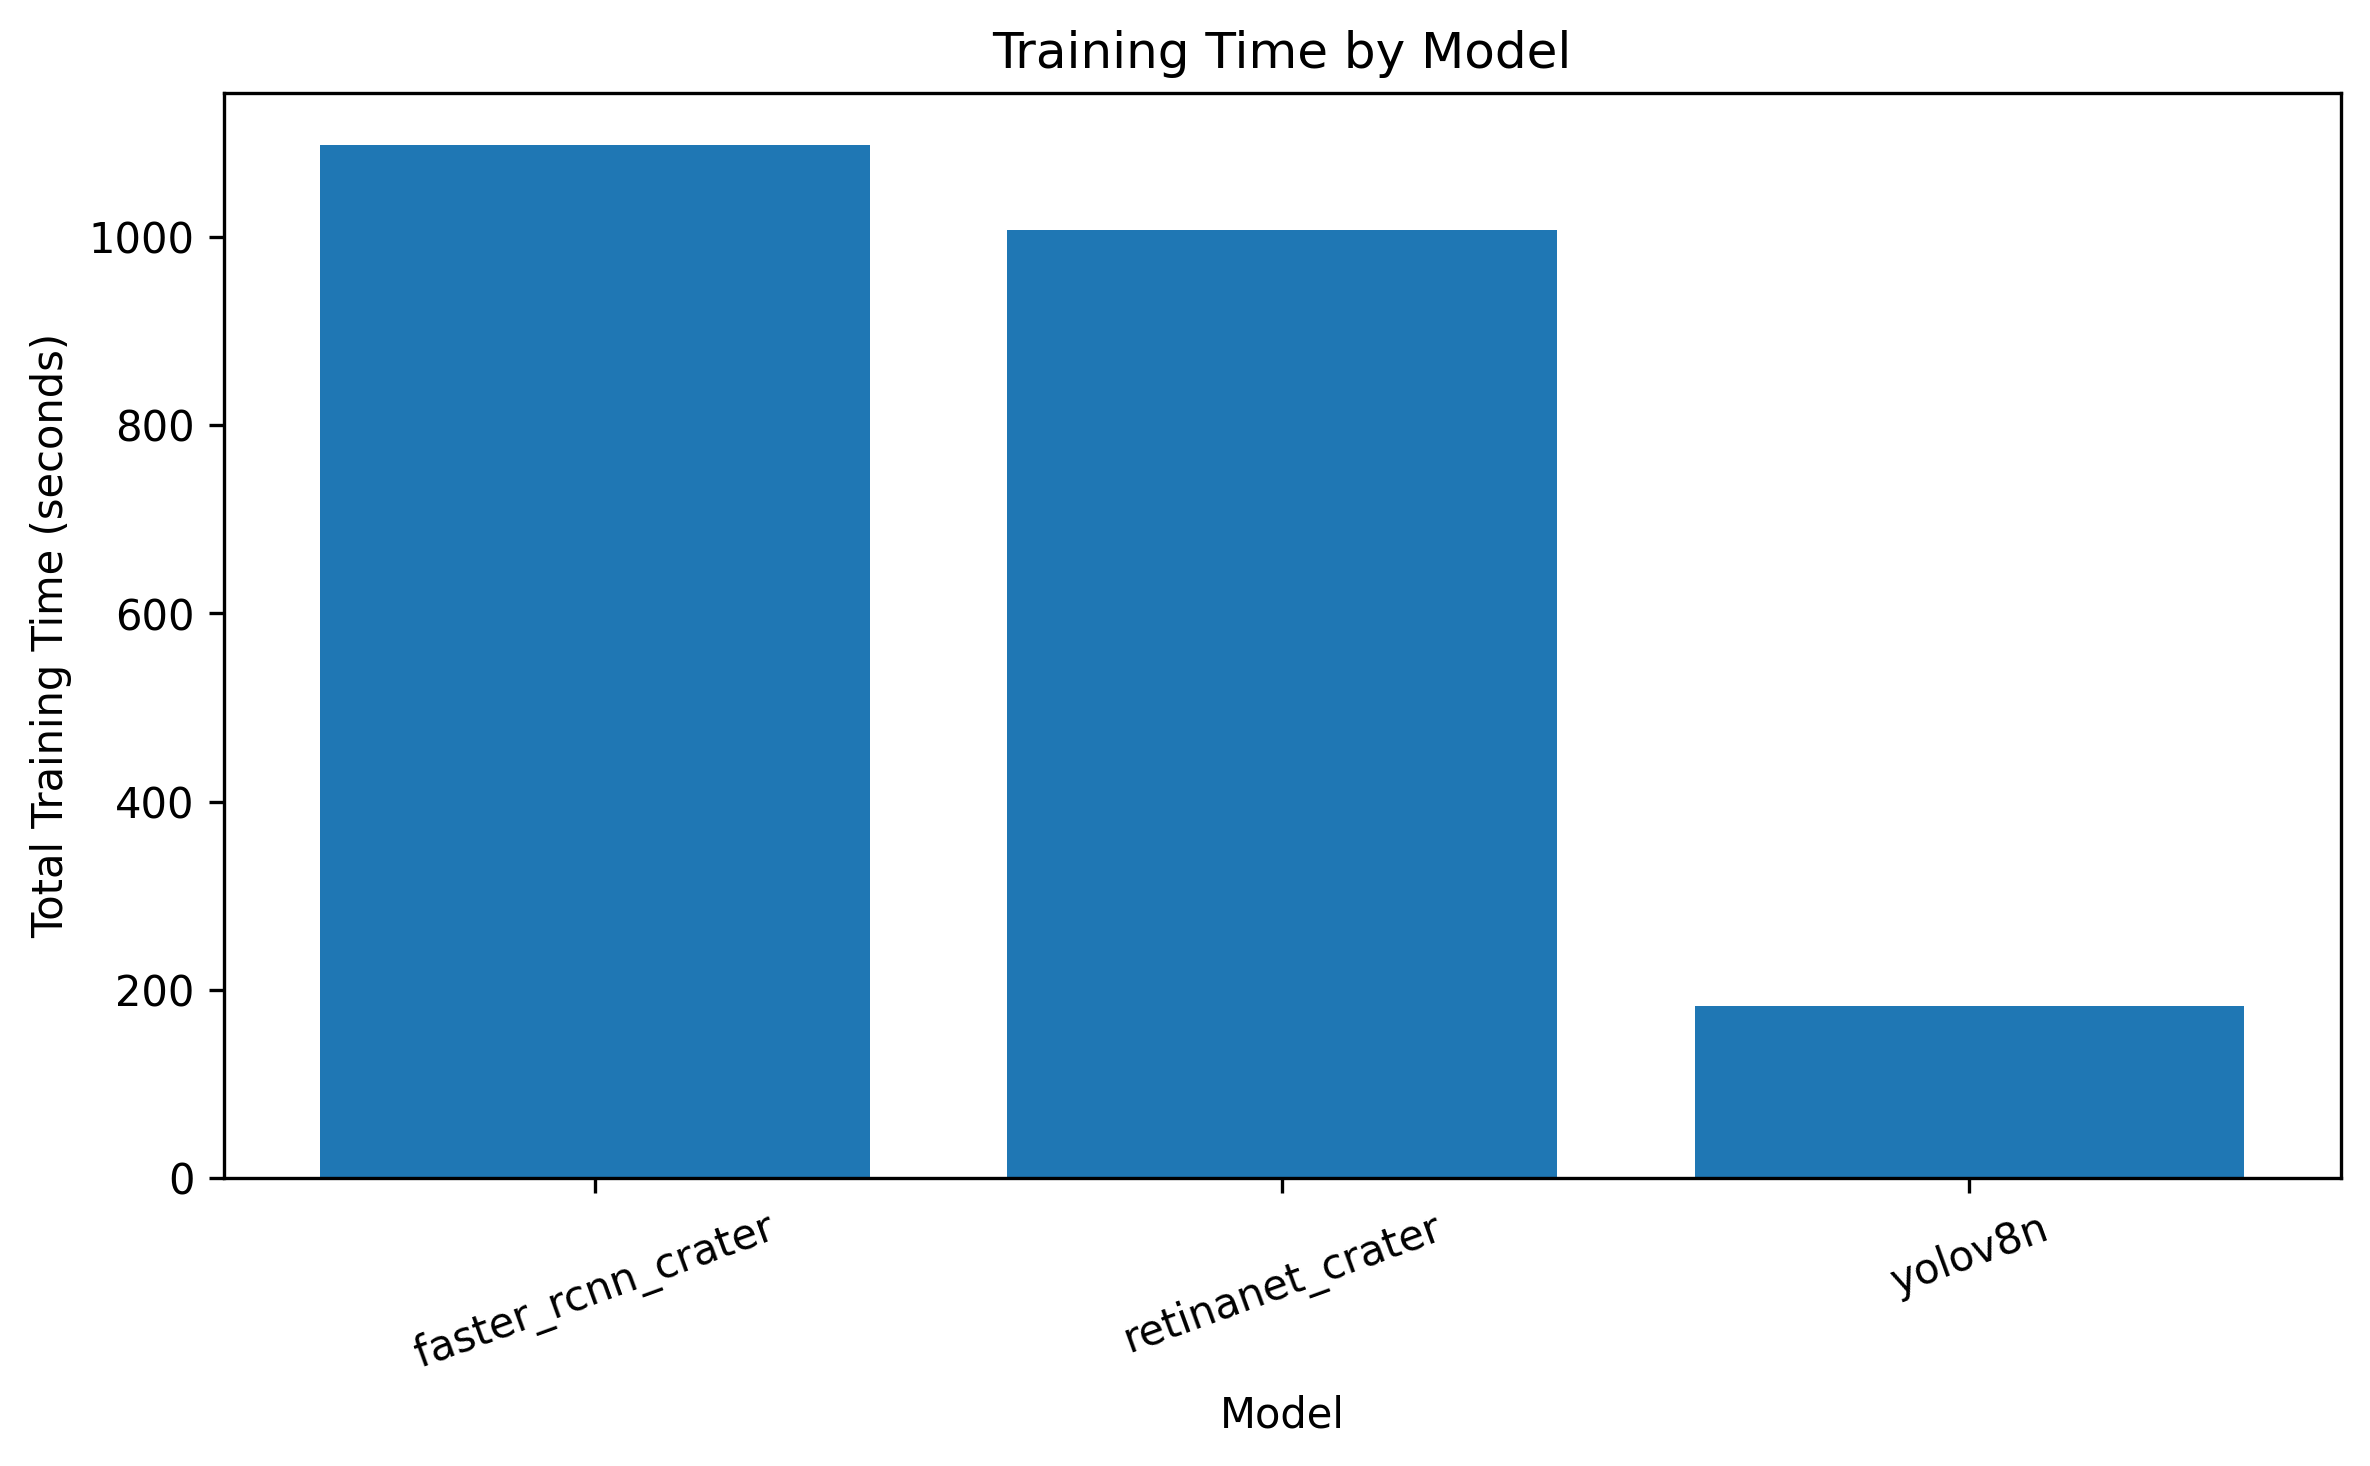

In [13]:
display(
    Image(
        filename=(
            "/content/drive/MyDrive/"
            "ece-533-final-project/"
            "comparison_outputs/plots/"
            "training_time_comparison.png"
        )
    )
)

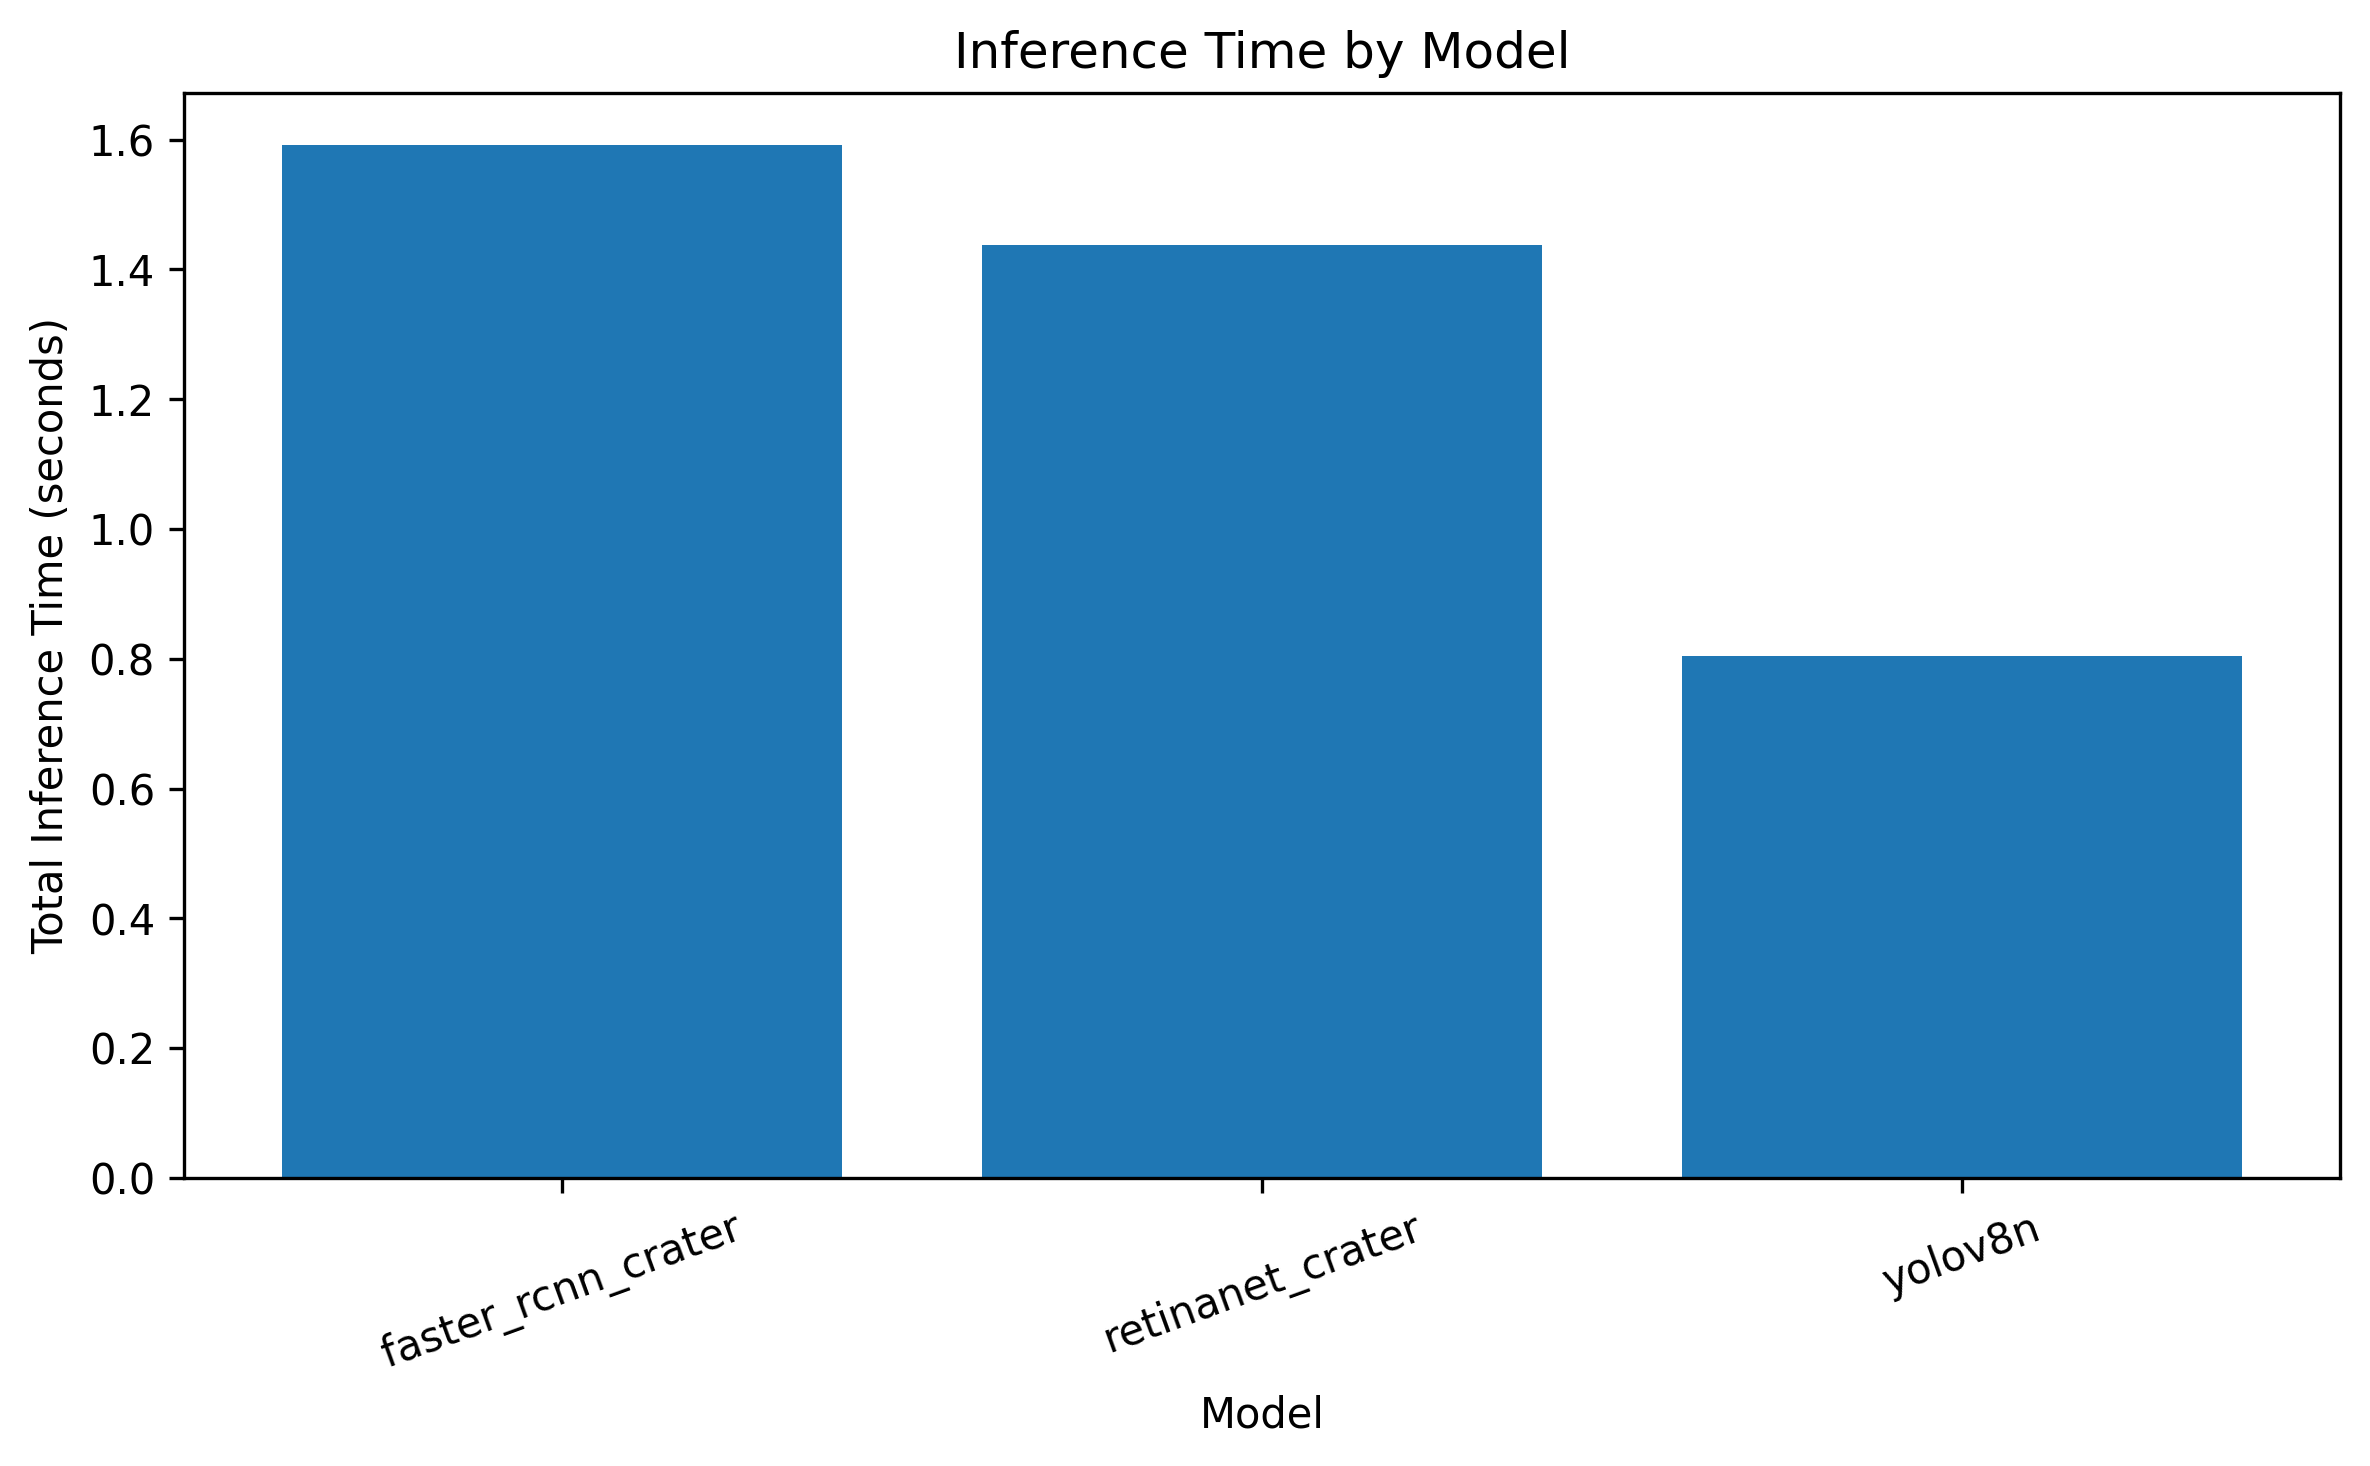

In [14]:
display(
    Image(
        filename=(
            "/content/drive/MyDrive/"
            "ece-533-final-project/"
            "comparison_outputs/plots/"
            "inference_time_comparison.png"
        )
    )
)

In [19]:
from pathlib import Path
from IPython.display import Image, display

project_dir = Path("/content/drive/MyDrive/ece-533-final-project")

ground_truth_dir = project_dir / "dataset_outputs" / "ground_truth"
yolo_dir = project_dir / "comparison_outputs" / "yolo"
faster_dir = project_dir / "comparison_outputs" / "faster_rcnn"
retina_dir = project_dir / "comparison_outputs" / "retinanet"

example_images = sorted(list(ground_truth_dir.glob("*.jpg")))[:5]

for gt_path in example_images:
    image_name = gt_path.name

    print(f"\nGround Truth: {image_name}")
    display(Image(filename=str(gt_path)))

    print("YOLO Prediction")
    display(Image(filename=str(yolo_dir / image_name)))

    print("Faster R-CNN Prediction")
    display(Image(filename=str(faster_dir / image_name)))

    print("RetinaNet Prediction")
    display(Image(filename=str(retina_dir / image_name)))

Output hidden; open in https://colab.research.google.com to view.

# 8. Conclusion

This project successfully developed and evaluated multiple deep learning object detection pipelines for automated lunar crater detection.

The full workflow included:

* dataset preparation
* dataset verification
* ground truth visualization
* model training
* prediction visualization
* quantitative evaluation
* computational performance analysis

Among the evaluated architectures, YOLOv8 demonstrated the best overall balance between crater detection accuracy, training speed, and inference efficiency.

The results demonstrate that modern deep learning object detection frameworks provide an effective and scalable solution for automated planetary crater analysis and future aerospace vision applications.

Future work could further improve performance through:

* larger crater datasets
* higher-resolution imagery
* advanced augmentation methods
* larger detection architectures
* segmentation-based crater detection
* embedded aerospace deployment optimization

---

# 9. References

1. Ultralytics YOLOv8
   https://github.com/ultralytics/ultralytics

2. TorchVision Object Detection Models
   https://pytorch.org/vision/stable/models.html

3. Lunar and Martian Crater Dataset
   https://www.kaggle.com/datasets/lincolnzh/martianlunar-crater-detection-dataset

4. PyTorch Documentation
   https://pytorch.org/
